# Imports

In [1]:
# %matplotlib qt5

%matplotlib notebook

import numpy as np
import matplotlib.pyplot as plt
from mathphys.functions import load, save
import mathphys.constants as cons
from pycolleff.longitudinal_equilibrium import ImpedanceSource, LongitudinalEquilibrium

from pycolleff.rings import maxiv, als, half, sirius

from pycolleff.longitudinal_equilibrium import _mytrapz

from pycolleff.colleff import Ring

import matplotlib as mplt
import matplotlib.cm as cmap

import scienceplots
from itertools import product

mplt.style.use('science')

plt.rcParams.update({
    'font.size': 18, 'axes.grid': True,
    'grid.linestyle': '--', 'grid.alpha': 0.5})

plt.rcParams['xtick.direction'] = 'out'
plt.rcParams['ytick.right'] = False
plt.rcParams['ytick.direction'] = 'out'
plt.rcParams['xtick.top'] = False

c = 299_792_458

# Methods

In [2]:
def calc_equilibrium_for_fixed_detuning(
    ring, mcav, hcav, current, detune, longeq=None
):
    """Calculate the equilibrium for a fixed cavity and current."""
    h = ring.harm_num    
    ring.total_current = current
    fill = np.ones(h)/h
    
    if longeq is None:
        longeq = LongitudinalEquilibrium(
            ring=ring, impedance_sources=[mcav, hcav, ],
            fillpattern=fill)
        longeq.feedback_on = False
        longeq.zgrid = np.linspace(-1, 1, 2001) * ring.rf_lamb/2
        # longeq.zgrid = np.linspace(-0.9, 0.9, 2001) * ring.rf_lamb/2
    else:
        longeq.ring = ring
        longeq.impedance_sources = [mcav, hcav]
        longeq.ring.total_current = current
        longeq.fillpattern = fill
    longeq.identical_bunches = True
    longeq.impedance_sources[-1].detune_w = 2*np.pi*detune
    _ = longeq.calc_longitudinal_equilibrium(
            niter=1_000, tol=1e-8, beta=0.1, print_flag=False, m=3)
    return longeq


def calc_equilibrium_for_flat_potential(
    ring, mcav, hcav, current, nr_iters=7, longeq=None, printout=False,
):
    """Calculate equilibrium to flat potential condition.

    This method will change the detune_angle of the cavity so that
    the beam induced voltage amplitude matches the flat potential
    condition.

    It will iterate a few times so that the form factor of the
    distribution converges.
    """
    h = ring.harm_num    
    fill = np.ones(h)/h
    ring.total_current = current
    
    if longeq is None:
        longeq = LongitudinalEquilibrium(
            ring=ring, impedance_sources=[mcav, hcav, ],
            fillpattern=fill)
        longeq.feedback_on = False
        longeq.zgrid = np.linspace(-1, 1, 2001) * ring.rf_lamb/2
        # longeq.zgrid = np.linspace(-0.9, 0.9, 2001) * ring.rf_lamb/2
    else:
        longeq.ring = ring
        longeq.impedance_sources = [mcav, hcav]
        longeq.ring.total_current = current
        longeq.fillpattern = fill
    longeq.identical_bunches = True
    
    for _ in range(nr_iters):
        kharm = longeq.calc_harmonic_voltage_for_flat_potential(harm_rf=hcav.harm_rf)
        vharm = kharm * longeq.ring.gap_voltage
        angle = longeq.calc_detune_for_fixed_harmonic_voltage(
            vharm, Rs=hcav.shunt_impedance, harm_rf=hcav.harm_rf)
        hcav.detune_angle = angle
        longeq.impedance_sources[-1] = hcav
        hvolt = longeq.calc_induced_voltage_impedance_dft(
            dist=longeq.distributions, imp_sources=[hcav])
        if printout:
            print(f'detune: {hcav.detune_w/2/np.pi/1e3:.3f} kHz')
            print(f'voltage: {np.mean(hvolt, axis=0).max()/1e3:.5f} kV')
        _ = longeq.calc_longitudinal_equilibrium(
                niter=1000, tol=1e-8, beta=0.1, print_flag=False, m=5)
    return longeq


################################################################################
def calc_lmci(
    longeq,
    cbmode=1,
    max_azi=2,
    max_rad=1,
    fokker=True,
    delete_m0=True,
    delete_m0k0=True,
    sync_method='sigma',
):
    """Calculate LMCI for a given coupled bunch mode and equilibrium condition.

    Args:
        longeq: object from Longitudinal equilibrium class;
        cbmode: coupled-bunch mode to evaluate must be in range [0, h-1].
            Defaults to 1, which is the mode of PTBL instability;
        max_azi: maximum azimuthal mode to consider in expansion.
            Detaults to 2. Found to be enough to explain PTBL instability;
        max_azi: maximum radial mode to consider in expansion. Defaults to 1.
            Also found to be enough to explain PTBL instability.

    Returns:
        eigenfreq: complex coherent eigen angular frequencies in [rad/s];
        freqshift: frequency of the most unstable mode in [Hz];
        grate: growth rate of the most unstable mode in [1/s];
        sync_freq: incoherent synchrotron frequency used in calculations [Hz];
        peak_hvolt: peak voltage of harmonic cavity [V].
    
    """  
    mcav = longeq.impedance_sources[0]
    hcav = longeq.impedance_sources[-1]
    hvolt = longeq.calc_induced_voltage_wake(
        dist=longeq.distributions, wake_source=hcav)
    peak_hvolt = np.max(np.abs(hvolt[0, :]))
    peak_mvolt = mcav.ref_amp

    print(f'current: {longeq.ring.total_current*1e3:.2f} mA')
    print(f'detune: {hcav.detune_w/2/np.pi/1e3:.3f} kHz')
    print(f'detune angle: {np.rad2deg(hcav.detune_angle):.1f} deg')
    print(f'R/Q: {hcav.shunt_impedance/hcav.Q:.1f} Ohm')
    print(f'HC voltage: {peak_hvolt/1e3:.1f} kV')
    ratio = peak_hvolt/peak_mvolt
    print(f'HC voltage ratio: {ratio:.3f}')

    wrf = longeq.ring.rf_ang_freq
    dist, pot = longeq.calc_distributions_from_voltage(longeq.total_voltage)
    z0, sigmaz = longeq.calc_moments(longeq.zgrid, dist[0])
    sigmaz = sigmaz[0]
    longeq.ring.bunlen = sigmaz

    # Calculate the equivalent synchrotron frequency:
    if sync_method.startswith('sigma'):
        # use fórmula based on bunch length:
        sync_freq = longeq.ring.espread * longeq.ring.mom_comp * c
        sync_freq /= sigmaz * 2 * np.pi
    elif sync_method.startswith('average'):
        # use average of distribution:
        longeq.calc_equilibrium_info(
            longeq.total_voltage, method="action", max_amp=5, nrpts=100)
        sync_freq = longeq.equilibrium_info['avg_sync_freq']
    elif sync_method.startswith('derivative'):
        # use average of square root of gap voltage:
        longeq.calc_equilibrium_info(
            longeq.total_voltage, method="derivative", max_amp=5, nrpts=100)
        sync_freq = longeq.equilibrium_info['avg_sync_freq']
    longeq.ring.sync_tune = sync_freq / longeq.ring.rev_freq
    
    print(f"sync. freq.: {longeq.ring.sync_tune * longeq.ring.rev_freq:.3f} Hz")
    print(f'bunch length: {longeq.ring.bunlen*1e3:.3f} mm')

    # Calculate Vlasov's equation eigen-frequencies:
    wrf = longeq.ring.rf_ang_freq
    reduced = False
    eigenfreq, *_ = longeq.calc_mode_coupling(
        w=[-10*wrf, +10*wrf], 
        cbmode=cbmode,
        max_azi=max_azi,
        max_rad=max_rad, 
        use_fokker=fokker,
        reduced=reduced,
        delete_m0=delete_m0,
        delete_m0k0=delete_m0k0,
    )

    # Find most unstable mode:
    idx = np.argmax(eigenfreq.imag)
    freqshift = eigenfreq.real[idx] / 2 / np.pi
    grate = eigenfreq.imag[idx]
    if reduced:
        # Subtract radiation damping rate from "reduced" simulation:
        grate -= 1/longeq.ring.dampte

    print('Most unstable mode:')
    print(f'    frequency: {freqshift:.2f} Hz')
    print(f'    growth rate: {grate:.2f} 1/s')
    print('\n')
    return eigenfreq, freqshift, grate, sync_freq, peak_hvolt


def calc_lmci_scan_current(ring, mcav, hcav, current_scan):
    """Calculate equilibrium and solve Vlasov equation for a current set.

    The cavity will be detuned to flat potential condition at each current.
    
    """
    growths, shifts, syncdata, peak_hvolts = [], [], [], []
    longeq = None
    cbmode = 1
    # cbpmode = ring.harm_num-1
    for i, current in enumerate(current_scan):
        longeq = calc_equilibrium_for_flat_potential(
            ring, mcav, hcav, current=current, nr_iters=8, longeq=longeq,
        )
        eigenfreq, tuneshift, grate, sync_freq, peak_hvolt = calc_lmci(
            longeq, cbmode=cbmode, max_azi=3, max_rad=2,
        )
        growths.append(grate)
        shifts.append(tuneshift)
        syncdata.append(sync_freq)
        peak_hvolts.append(peak_hvolt)
    growths = np.array(growths)
    shifts = np.array(shifts)
    syncdata = np.array(syncdata)
    peak_hvolts = np.array(peak_hvolts)
    return growths, shifts, syncdata, peak_hvolts


def calc_lmci_scan_detuning(
    ring,
    mcav, 
    hcav,
    current,
    detuning_scan,
    fokker=True,
    delete_m0=True,
    delete_m0k0=True,
    sync_method='sigma',
):
    """Calculate equilibrium and solve Vlasov equation for a detuning set."""
    growths, shifts, syncdata, peak_hvolts = [], [], [], []
    longeq = None
    cbmode = 1
    # cbpmode = ring.harm_num-1
    for i, detune in enumerate(detuning_scan):
        longeq = calc_equilibrium_for_fixed_detuning(
            ring, mcav, hcav, current, detune=detune, longeq=longeq,
        )
        eigenfreq, tuneshift, grate, sync_freq, peak_hvolt = calc_lmci(
            longeq,
            cbmode=cbmode,
            max_azi=3,
            max_rad=2,
            fokker=fokker,
            delete_m0=delete_m0,
            delete_m0k0=delete_m0k0,
            sync_method=sync_method,
        )
        growths.append(grate)
        shifts.append(tuneshift)
        syncdata.append(sync_freq)
        peak_hvolts.append(peak_hvolt)
    growths = np.array(growths)
    shifts = np.array(shifts)
    syncdata = np.array(syncdata)
    peak_hvolts = np.array(peak_hvolts)
    return growths, shifts, syncdata, peak_hvolts

# MAX-IV

In [3]:
ring = maxiv.create_ring(energy=3)
ring.gap_voltage = 1.397e6
ring.total_current = 300e-3

print(ring)

Lattice Version             :     MAX-IV-3GeV     
Circumference [m]           :       527.999       
Revolution Period [us]      :        1.761        
Revolution Frequency [kHz]  :       567.790       
Energy [GeV]                :        3.000        
U0 [keV]                    :       363.800       
Vgap [MV]                   :        1.397        
Momentum Compaction         :       3.06e-04      
Harmonic Number             :         176         
Current [mA]                :       300.000       
Current per Bunch [mA]      :        1.705        
Synchrotron Tune            :       0.00164       
Tunes x/y                   :    16.280/42.200    
Chromaticities x/y          :     1.000/1.000     
Damping Times x/y/e [ms]    :   15.7/ 29.0 /25.2  
Energy Spread [%]           :        0.0769       
Bunch Length [mm]           :        10.694       



In [4]:
mcav = ImpedanceSource()
Rs0 = 1.71e6
Q0 = 20_248
beta = 4.5
ncavs = 4

mcav.harm_rf = 1
mcav.shunt_impedance = Rs0 * ncavs 
mcav.Q = 20_800
mcav.beta_coupling = beta

twopi = 2*np.pi
wrf = twopi*ring.rf_freq
mcav.ang_freq_rf = wrf
mcav.ang_freq = mcav.harm_rf*wrf

mcav.ref_amp = ring.gap_voltage
mcav.ref_phase = ring.sync_phase

df = mcav.optimum_detuning_freq(beam_current=ring.total_current)
mcav.detune_w = twopi*df
mcav.feedback_on = True

mcav.active_passive = ImpedanceSource.ActivePassive.Active

# If you do not want to worry about the details of the voltage gap
# control system, you can use SIRIUS parameters below.
delay = 1.9e-6
ki = 0.01
kp = 2.96e-6
kd = 0
gain = 1 * 0
mcav.loop_ctrl_ang_freq = twopi * ring.rf_freq
mcav.loop_ctrl_kpid = [kp, ki, kd]
mcav.loop_ctrl_overall_gain = gain
mcav.loop_ctrl_delay = delay
mcav.loop_ctrl_transfer = mcav.pid_transfer_func
mcav.calc_method = ImpedanceSource.Methods.ImpedanceDFT

# mcav.calc_method = ImpedanceSource.Methods.Wake

print(mcav)

calc_method              : ImpedanceDFT  
active_passive           : Active  
ang_freq_rf              : 627.88  [Mrad/s]
ang_freq                 : 627.84  [Mrad/s]
shunt_impedance          : 6.84  [MOhm]
Q                        : 2.08e+04  
RoverQ                   : 328.85  [Ohm]
beta_coupling            : 4.50  
harm_rf                  : 1.00  
detune_angle             : -0.48  [rad]
detune_freq              : -6.81  [kHz]
detune_w                 : -42.81  [krad/s]
alpha                    : 83007.98  [rad/s]
ang_freq_bar             : 627.84  [Mrad/s]
loaded_shunt_impedance   : 1.24  [MOhm]
loaded_Q                 : 3.78e+03  
feedback_on              : True  
feedback_method          : Phasor  
ref_amp                  : 1397.00  [kV]
ref_phase                : 164.91  [deg]



In [5]:
hcav = ImpedanceSource()
hcav.harm_rf = 3
hcav.Q = 20_800
ncavs = 3
hcav.shunt_impedance = 2.75e6 * ncavs 

twopi = 2*np.pi
hcav.ang_freq_rf = twopi*ring.rf_freq
hcav.ang_freq = hcav.harm_rf*hcav.ang_freq_rf

hcav.detune_w = twopi*25e3
hcav.calc_method = ImpedanceSource.Methods.ImpedanceDFT
hcav.active_passive = ImpedanceSource.ActivePassive.Passive

In [6]:
longeq = calc_equilibrium_for_flat_potential(
    ring, mcav, hcav, current=300e-3, nr_iters=15, longeq=None, printout=True)

detune: 79.230 kHz
voltage: 447.68866 kV
detune: 76.771 kHz
voltage: 447.68020 kV
detune: 75.931 kHz
voltage: 447.68115 kV
detune: 75.580 kHz
voltage: 447.67992 kV
detune: 75.423 kHz
voltage: 447.67920 kV
detune: 75.351 kHz
voltage: 447.67884 kV
detune: 75.318 kHz
voltage: 447.67866 kV
detune: 75.302 kHz
voltage: 447.67858 kV
detune: 75.295 kHz
voltage: 447.67854 kV
detune: 75.291 kHz
voltage: 447.67853 kV
detune: 75.290 kHz
voltage: 447.67852 kV
detune: 75.289 kHz
voltage: 447.67851 kV
detune: 75.289 kHz
voltage: 447.67851 kV
detune: 75.289 kHz
voltage: 447.67851 kV
detune: 75.288 kHz
voltage: 447.67851 kV


In [7]:
current_scan = np.linspace(250, 400, 30)*1e-3
grate, freq, sync_freq, peak_hvolt = calc_lmci_scan_current(ring, mcav, hcav, current_scan)

current: 250.00 mA
detune: 62.584 kHz
detune angle: 83.4 deg
R/Q: 396.6 Ohm
HC voltage: 447.6 kV
HC voltage ratio: 0.320
sync. freq.: 217.144 Hz
bunch length: 51.706 mm
Most unstable mode:
    frequency: 130.54 Hz
    growth rate: -26.90 1/s


current: 255.17 mA
detune: 63.888 kHz
detune angle: 83.6 deg
R/Q: 396.6 Ohm
HC voltage: 447.7 kV
HC voltage ratio: 0.320
sync. freq.: 217.081 Hz
bunch length: 51.721 mm
Most unstable mode:
    frequency: 126.02 Hz
    growth rate: -25.79 1/s


current: 260.34 mA
detune: 65.203 kHz
detune angle: 83.7 deg
R/Q: 396.6 Ohm
HC voltage: 447.7 kV
HC voltage ratio: 0.320
sync. freq.: 217.199 Hz
bunch length: 51.693 mm
Most unstable mode:
    frequency: 121.68 Hz
    growth rate: -24.61 1/s


current: 265.52 mA
detune: 66.518 kHz
detune angle: 83.8 deg
R/Q: 396.6 Ohm
HC voltage: 447.7 kV
HC voltage ratio: 0.320
sync. freq.: 217.324 Hz
bunch length: 51.663 mm
Most unstable mode:
    frequency: 117.12 Hz
    growth rate: -23.30 1/s


current: 270.69 mA
detun

<IPython.core.display.Javascript object>


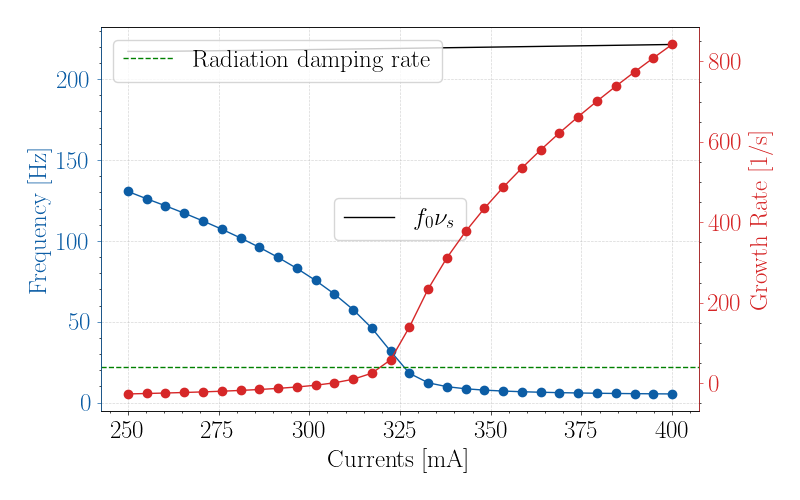

In [8]:
fig, ax = plt.subplots(1, 1, figsize=(8, 5))
ay = ax.twinx()

ax.plot(current_scan*1e3, freq, 'o-')
ax.plot(current_scan*1e3, sync_freq, color='k', label=r'$f_0\nu_s$')
ay.plot(current_scan*1e3, np.array(grate), 'o-', color='tab:red')

ay.grid(False)
ay.spines['right'].set_color('tab:red')
# plt.setp(ay.yaxis.get_ticklabels(), color='tab:red')
ay.tick_params(axis='y', colors='tab:red')

ay.spines['left'].set_color('C0')
plt.setp(ax.yaxis.get_ticklabels(), color='tab:red')
ax.tick_params(axis='y', colors='C0')

ax.legend(loc='center', frameon=True)
ax.set_ylabel('Frequency [Hz]', color='C0')
ax.set_xlabel('Currents [mA]')
ay.set_ylabel('Growth Rate [1/s]', color='tab:red')
ay.axhline(1/ring.dampte, color='g', label='Radiation damping rate', ls='--')
ay.legend(frameon=True)
fig.tight_layout()
fig.show()

In [9]:
current = 300e-3
# detune_scan = np.linspace(77.5, 73.5, 20)*1e3
detune_scan = np.linspace(80, 73.5, 20)*1e3
# detune_scan = detune_scan[:14]
fokker = True
delete_m0 = True
delete_m0k0 = True
sync_method = 'average'
grate, freq, sync_freq, peak_hvolt = calc_lmci_scan_detuning(
    ring,
    mcav,
    hcav,
    current,
    detune_scan,
    fokker=fokker,
    delete_m0=delete_m0,
    delete_m0k0=delete_m0k0,
    sync_method=sync_method,
)

current: 300.00 mA
detune: 80.000 kHz
detune angle: 84.9 deg
R/Q: 396.6 Ohm
HC voltage: 430.9 kV
HC voltage ratio: 0.308
sync. freq.: 266.507 Hz
bunch length: 39.300 mm
Most unstable mode:
    frequency: 185.89 Hz
    growth rate: -27.61 1/s


current: 300.00 mA
detune: 79.658 kHz
detune angle: 84.8 deg
R/Q: 396.6 Ohm
HC voltage: 432.3 kV
HC voltage ratio: 0.309


/Users/murbar/repos/collective_effects/pycolleff/pycolleff/longitudinal_equilibrium.py:1216: IntegrationWarning: The occurrence of roundoff error is detected, which prevents 
  the requested tolerance from being achieved.  The error may be 
  underestimated.
  action, _ = _quad(intg, zli, zri, points=[zli, zri])


sync. freq.: 260.220 Hz
bunch length: 40.038 mm
Most unstable mode:
    frequency: 175.82 Hz
    growth rate: -26.85 1/s


current: 300.00 mA
detune: 79.316 kHz
detune angle: 84.8 deg
R/Q: 396.6 Ohm
HC voltage: 433.6 kV
HC voltage ratio: 0.310


/Users/murbar/repos/collective_effects/pycolleff/pycolleff/longitudinal_equilibrium.py:1216: IntegrationWarning: The occurrence of roundoff error is detected, which prevents 
  the requested tolerance from being achieved.  The error may be 
  underestimated.
  action, _ = _quad(intg, zli, zri, points=[zli, zri])
/Users/murbar/repos/collective_effects/pycolleff/pycolleff/longitudinal_equilibrium.py:1216: IntegrationWarning: The occurrence of roundoff error is detected, which prevents 
  the requested tolerance from being achieved.  The error may be 
  underestimated.
  action, _ = _quad(intg, zli, zri, points=[zli, zri])


sync. freq.: 253.914 Hz
bunch length: 40.799 mm
Most unstable mode:
    frequency: 165.21 Hz
    growth rate: -25.92 1/s


current: 300.00 mA
detune: 78.974 kHz
detune angle: 84.8 deg
R/Q: 396.6 Ohm
HC voltage: 434.9 kV
HC voltage ratio: 0.311


...

/Users/murbar/repos/collective_effects/pycolleff/pycolleff/longitudinal_equilibrium.py:1216: IntegrationWarning: The occurrence of roundoff error is detected, which prevents 
  the requested tolerance from being achieved.  The error may be 
  underestimated.
  action, _ = _quad(intg, zli, zri, points=[zli, zri])
/Users/murbar/repos/collective_effects/pycolleff/pycolleff/longitudinal_equilibrium.py:1203: RuntimeWarning: invalid value encountered in sqrt
  return _np.sqrt((2 / alpha) * (h0i - phi))
/Users/murbar/repos/collective_effects/pycolleff/pycolleff/longitudinal_equilibrium.py:1216: IntegrationWarning: The occurrence of roundoff error is detected, which prevents 
  the requested tolerance from being achieved.  The error may be 
  underestimated.
  action, _ = _quad(intg, zli, zri, points=[zli, zri])


sync. freq.: 234.135 Hz
bunch length: 55.877 mm
Most unstable mode:
    frequency: 118.54 Hz
    growth rate: -19.13 1/s


current: 300.00 mA
detune: 73.500 kHz
detune angle: 84.4 deg
R/Q: 396.6 Ohm
HC voltage: 453.0 kV
HC voltage ratio: 0.324


/Users/murbar/repos/collective_effects/pycolleff/pycolleff/longitudinal_equilibrium.py:1203: RuntimeWarning: invalid value encountered in sqrt
  return _np.sqrt((2 / alpha) * (h0i - phi))
/Users/murbar/repos/collective_effects/pycolleff/pycolleff/longitudinal_equilibrium.py:1216: IntegrationWarning: The occurrence of roundoff error is detected, which prevents 
  the requested tolerance from being achieved.  The error may be 
  underestimated.
  action, _ = _quad(intg, zli, zri, points=[zli, zri])


sync. freq.: 6.771 Hz
bunch length: 56.956 mm
Most unstable mode:
    frequency: 2.04 Hz
    growth rate: 1644.18 1/s




/Users/murbar/repos/collective_effects/pycolleff/pycolleff/longitudinal_equilibrium.py:1216: IntegrationWarning: The occurrence of roundoff error is detected, which prevents 
  the requested tolerance from being achieved.  The error may be 
  underestimated.
  action, _ = _quad(intg, zli, zri, points=[zli, zri])
/Users/murbar/repos/collective_effects/pycolleff/pycolleff/longitudinal_equilibrium.py:1216: IntegrationWarning: The occurrence of roundoff error is detected, which prevents 
  the requested tolerance from being achieved.  The error may be 
  underestimated.
  action, _ = _quad(intg, zli, zri, points=[zli, zri])
/Users/murbar/repos/collective_effects/pycolleff/pycolleff/longitudinal_equilibrium.py:1203: RuntimeWarning: invalid value encountered in sqrt
  return _np.sqrt((2 / alpha) * (h0i - phi))
/Users/murbar/repos/collective_effects/pycolleff/pycolleff/longitudinal_equilibrium.py:1216: IntegrationWarning: The occurrence of roundoff error is detected, which prevents 
  the req

<IPython.core.display.Javascript object>


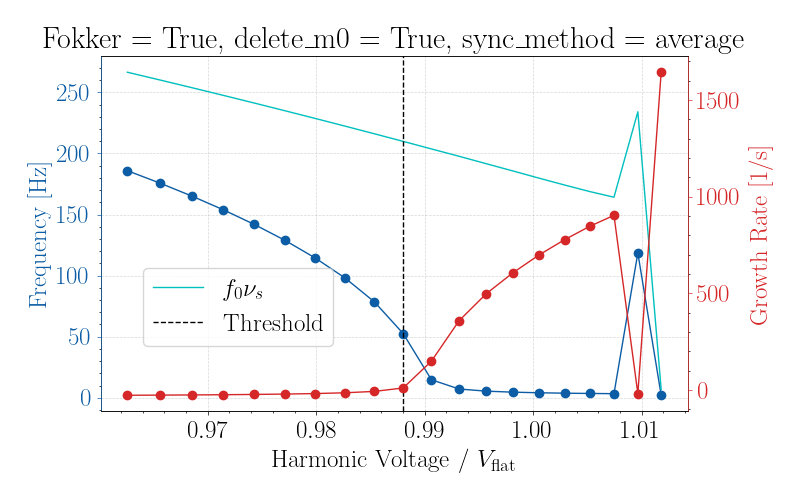

In [10]:
fig, ax = plt.subplots(1, 1, figsize=(8, 5))
ay = ax.twinx()

hvol = peak_hvolt / 447.67822e3
ax.plot(hvol, freq, 'o-')
ax.plot(hvol, sync_freq, 'c', label=r'$f_0\nu_s$')
ay.plot(hvol, grate, 'o-', color='tab:red')
ax.axvline(
    hvol[(grate>0).nonzero()[0][0]],
    ls='--',
    color='k',
    label='Threshold',
)

ay.grid(False)
ay.spines['right'].set_color('tab:red')
# plt.setp(ay.yaxis.get_ticklabels(), color='tab:red')
ay.tick_params(axis='y', colors='tab:red')

ay.spines['left'].set_color('C0')
plt.setp(ax.yaxis.get_ticklabels(), color='tab:red')
ax.tick_params(axis='y', colors='C0')

ax.set_title(
    f'Fokker = {fokker}, delete_m0 = {delete_m0}, sync_method = {sync_method:s}')

ax.legend(loc='lower left', frameon=True, bbox_to_anchor=(0.05, 0.15))
ax.set_ylabel('Frequency [Hz]', color='C0')
ax.set_xlabel(r'Harmonic Voltage / $V_\text{flat}$')
# ax.set_xlabel('Harmonic Voltage [kV]')
ay.set_ylabel('Growth Rate [1/s]', color='tab:red')
fig.tight_layout()
fig.show()